In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, time, timedelta
from SynthSpread.spreadviewer_class import SpreadSingle, SpreadViewerData, norm_coeff
#from Database.TPData import TPData, TPDataDa, TPDataAssembly

from Strategies.LeadLagXGB.backtest_class import BacktestLL
from Strategies.LeadLagXGB.strategy_class import StrategyLL, VolumeClass
tol=(1e-1)/2

In [25]:
%load_ext autoreload
%autoreload 2

In [26]:
import warnings
warnings.filterwarnings('ignore')

In [27]:
#5	17	0.1	1.00	-0.75	

In [ ]:
#0.08	-0.08	0.08	-0.10	1.5	60	0.3	0.6	0.50	2.0	-2.0

In [28]:
#0.04	-0.04	0.06	-0.06	1.2	60	0.3	0.6	0.8 2.0	-1.5 -> around 40, stable perf
#0.04	-0.04	0.06	-0.06	0.7	60	0.3	0.6	0.8	 2.0	-1 -> around 51, weak perf on prod sample
#0.075	-0.050	0.150	-0.100	0.45	60	0.3	0.6	0.8	 2.0	-1 -> around 41, good stable performance overall
#other combinations do not work well on prod sample

In [29]:
MACD_long_threshold = 0.075
MACD_short_threshold = -0.050
price_diff_long_threshold = 0.150
price_diff_short_threshold = -0.100

combined_long_threshold = 0.2
combined_short_threshold = 0.2

combined_mode=False
minimum_intensity=0.45

burnout_period=60
stop_profit = 0.3
makeagg_ratio = 0.6
trail_stop=0.3

take_profit=1
stop_loss=-1
aggloss_thres=0.04

fit_reg_coef=True
coef1=0.00000001
coef2=0.35

br_fee = 0.0175
closing_mode='Martinovo_zatvaranie'

In [30]:
%store -r dates_fltr

# OOT part - Mar,Apr

## Data preparation

In [10]:
data_lead = pd.read_parquet(r's:\Algo\Files\andrej\Data\int_data_lead_dem1_mar_apr.parquet', engine='fastparquet').reset_index()
data_lag = pd.read_parquet(r's:\Algo\Files\andrej\Data\int_data_lag_dem2_mar_apr.parquet', engine='fastparquet').reset_index()

In [11]:
data_lag['time_diff']=data_lag['datetime'].diff().dt.total_seconds().fillna(0)

In [12]:
data_lead=data_lead[data_lead['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]
data_lag=data_lag[data_lag['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]

In [13]:
#data_lag=data_lag.drop(index=177223).reset_index()
del data_lag['level_0']
del data_lead['level_0']

In [14]:
data_lag.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side,time_diff
1279,1279,2024-03-01 09:00:00,NaN,NaN,52.97,53.45,53.210,1,1.0
1280,1280,2024-03-01 09:00:01,NaN,NaN,52.97,53.41,53.190,1,1.0
1281,1281,2024-03-01 09:00:02,NaN,NaN,52.76,53.35,53.055,1,1.0
1282,1282,2024-03-01 09:00:03,NaN,NaN,52.83,53.31,53.070,1,1.0
1283,1283,2024-03-01 09:00:04,NaN,NaN,52.87,53.31,53.090,1,1.0


In [15]:
data_lead.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side
15,15,2024-03-01 09:00:09.338750124,56.41,2.0,56.41,56.61,56.510,0
16,16,2024-03-01 09:03:07.821218967,56.65,1.0,56.47,56.65,56.560,1
17,17,2024-03-01 09:03:07.821283579,56.70,5.0,56.47,56.65,56.560,1
18,18,2024-03-01 09:03:08.110189915,56.73,1.0,56.49,56.65,56.570,1
19,19,2024-03-01 09:03:14.834126711,56.90,1.0,56.72,56.89,56.805,1


## Parameters and calculations

In [16]:
instr = 'm2'

contr_vars = []

param_list = ['t_end', 'take_profit', 'stop_loss']
param_dict = {k: [] for k in param_list}
param_dict['t_end'] = time(17)
param_dict['take_profit'] = take_profit
param_dict['stop_loss'] = stop_loss
param_dict['ba_max']=0.3
param_dict['aggloss_thres']=aggloss_thres


param_dict['br_fee'] = br_fee

param_dict['MACD_long_threshold'] = MACD_long_threshold
param_dict['MACD_short_threshold'] = MACD_short_threshold
param_dict['price_diff_long_threshold'] = price_diff_long_threshold
param_dict['price_diff_short_threshold'] = price_diff_short_threshold

param_dict['combined_long_threshold'] = combined_long_threshold
param_dict['combined_short_threshold'] = combined_short_threshold

param_dict['minimum_intensity'] = minimum_intensity

param_dict['burnout_period']=burnout_period
param_dict['stop_profit']=stop_profit
param_dict['makeagg_ratio']=makeagg_ratio
param_dict['trail_stop']=trail_stop

param_dict['combined_mode'] = combined_mode

param_dict['fit_reg_coef'] = fit_reg_coef
param_dict['coef1'] = coef1
param_dict['coef2'] = coef2



vol_class = VolumeClass(1, {'max_clips': 1})
backtest_class = BacktestLL(vol_class)
# model_class = HawkesIntensity
strategy_class = StrategyLL(
                            strategy='LL',
                            market='de',
                            instrument=instr, 
                            is_overnight=False,
                            closing_mode=closing_mode)

strategy_class.load_params(param_dict, contr_vars)

xx = backtest_class.simulate_strategy(strategy_class, instr, data_lag, data_lead)

df = pd.DataFrame({k: strategy_class.stats_dict[k] for k in list(strategy_class.stats_dict.keys()) if k in ['timestamp', 'position', 'price_level']})
df = pd.concat([df, ])

Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko


## Results

In [17]:
# from bokeh.plotting import figure, show, output_file
# from bokeh.models import ColumnDataSource, Range1d, LinearAxis, HoverTool
# import pandas as pd

# # Assuming 'data_lag', 'data_lead', and 'df' are already defined as per your context

# # Convert 'timestamp' to datetime if not already
# df['timestamp'] = pd.to_datetime(df['timestamp'])
# df['price_level']=df['price_level']-df['position']*br_fee

# # Assign color based on 'position' value
# df['color'] = df['position'].map({1: 'green', -1: 'red', 0: 'black'})

# # Create ColumnDataSources
# source_df = ColumnDataSource(df)
# source_lead = ColumnDataSource(data_lead)
# source_lag = ColumnDataSource(data_lag)

# # Create a figure with dynamic sizing
# p = figure(x_axis_type="datetime", title="Strategy Positions", sizing_mode='stretch_both')

# # Adjust y-axes ranges
# p.extra_y_ranges = {
#    "Lead price": Range1d(start=data_lead['trd_price'].min(), end=data_lead['trd_price'].max()),
#    "Lag price": Range1d(start=data_lag['trd_price'].min(), end=data_lag['trd_price'].max())
# }

# # Add left and right y-axes
# p.add_layout(LinearAxis(y_range_name="Lead price", axis_label="Lead Price"), 'left')
# p.add_layout(LinearAxis(y_range_name="Lag price", axis_label="Lag Price"), 'right')

# # Plotting with hover tools
# lead_crosses = p.cross(x='datetime', y='trd_price', source=source_lead, size=10, color='blue', legend_label="Lead Price", y_range_name="Lead price")
# lag_crosses = p.cross(x='datetime', y='trd_price', source=source_lag, size=10, color='orange', legend_label="Lag Price", y_range_name="Lag price")
# position_circles = p.circle(x='timestamp', y='price_level', source=source_df, size=10, color='color', legend_label="Position", y_range_name="Lag price")

# # Define hover tools for each glyph
# hover_position = HoverTool(renderers=[position_circles], tooltips=[
#     ("Timestamp", "@timestamp{%F %T}"),
#     ("Price Level", "@price_level"),
#     ("Position", "@position"),
#     ("Color", "@color"),
# ], formatters={'@timestamp': 'datetime'})

# hover_lead = HoverTool(renderers=[lead_crosses], tooltips=[
#     ("Datetime", "@datetime{%F %T}"),
#     ("Lead Price", "@trd_price"),
# ], formatters={'@datetime': 'datetime'})

# hover_lag = HoverTool(renderers=[lag_crosses], tooltips=[
#     ("Datetime", "@datetime{%F %T}"),
#     ("Lag Price", "@trd_price"),
# ], formatters={'@datetime': 'datetime'})

# # Add hover tools to the plot
# p.add_tools(hover_position, hover_lead, hover_lag)

# # Customize plot
# p.legend.location = "top_left"
# p.xaxis.axis_label = "Datetime"
# p.yaxis.axis_label = "Price Level"

# # Show the plot
# show(p)

<Axes: >

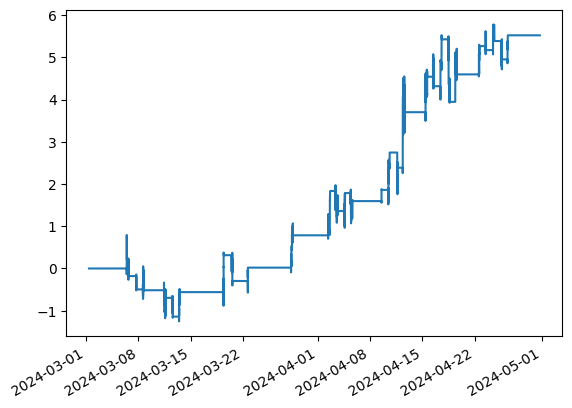

In [18]:
xx.plot()

In [19]:
#df[0:50]

In [20]:
xx[-1:]

2024-04-30 17:59:58    5.52
dtype: float64

# OOT part - May, Jun

## Data preparation

In [21]:
data_lead = pd.read_parquet(r's:\Algo\Files\andrej\Data\int_data_lead_dem1_may_june.parquet', engine='fastparquet').reset_index()
data_lag = pd.read_parquet(r's:\Algo\Files\andrej\Data\int_data_lag_dem2_may_june.parquet', engine='fastparquet').reset_index()

In [22]:
data_lead['datetime']=pd.to_datetime(data_lead['datetime'], format='mixed')
data_lag['datetime']=pd.to_datetime(data_lag['datetime'], format='mixed')

In [23]:
data_lag['time_diff']=data_lag['datetime'].diff().dt.total_seconds().fillna(0)

In [24]:
data_lead=data_lead[data_lead['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]
data_lag=data_lag[data_lag['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]

In [25]:
del data_lag['level_0']
del data_lead['level_0']
data_lag=data_lag.drop(index=49887).reset_index()
del data_lag['level_0']


In [26]:
data_lag.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side,time_diff
0,875,2024-05-02 09:00:02,NaN,NaN,68.90,70.93,69.915,1,17.0
1,876,2024-05-02 09:00:39,NaN,NaN,68.90,70.94,69.920,1,37.0
2,877,2024-05-02 09:01:01,NaN,NaN,68.88,70.94,69.910,1,22.0
3,878,2024-05-02 09:01:02,NaN,NaN,68.86,70.94,69.900,1,1.0
4,879,2024-05-02 09:01:54,NaN,NaN,68.82,70.94,69.880,1,52.0


In [27]:
data_lead.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side
35,35,2024-05-02 09:02:02.465197325,65.81,2.0,65.81,66.15,65.980,0
36,36,2024-05-02 09:03:31.473956823,66.00,1.0,65.75,65.99,65.870,1
37,37,2024-05-02 09:03:31.575801849,66.00,1.0,65.75,65.99,65.870,1
38,38,2024-05-02 09:03:32.014014244,65.99,1.0,65.75,65.99,65.870,1
39,39,2024-05-02 09:04:00.009787560,65.99,1.0,65.76,65.95,65.855,1


## Parameters and calculations

In [28]:
instr = 'm2'

contr_vars = []

param_list = ['t_end', 'take_profit', 'stop_loss']
param_dict = {k: [] for k in param_list}
param_dict['t_end'] = time(17)
param_dict['take_profit'] = take_profit
param_dict['stop_loss'] = stop_loss
param_dict['ba_max']=0.3
param_dict['aggloss_thres']=aggloss_thres

param_dict['br_fee'] = br_fee

param_dict['MACD_long_threshold'] = MACD_long_threshold
param_dict['MACD_short_threshold'] = MACD_short_threshold
param_dict['price_diff_long_threshold'] = price_diff_long_threshold
param_dict['price_diff_short_threshold'] = price_diff_short_threshold

param_dict['combined_long_threshold'] = combined_long_threshold
param_dict['combined_short_threshold'] = combined_short_threshold

param_dict['minimum_intensity'] = minimum_intensity

param_dict['burnout_period']=burnout_period
param_dict['stop_profit']=stop_profit
param_dict['makeagg_ratio']=makeagg_ratio
param_dict['trail_stop']=trail_stop

param_dict['combined_mode'] = combined_mode

param_dict['fit_reg_coef'] = fit_reg_coef
param_dict['coef1'] = coef1
param_dict['coef2'] = coef2



vol_class = VolumeClass(1, {'max_clips': 1})
backtest_class = BacktestLL(vol_class)
# model_class = HawkesIntensity
strategy_class = StrategyLL(
                            strategy='LL',
                            market='de',
                            instrument=instr, 
                            is_overnight=False,
                            closing_mode=closing_mode)

strategy_class.load_params(param_dict, contr_vars)

xx = backtest_class.simulate_strategy(strategy_class, instr, data_lag, data_lead)

df = pd.DataFrame({k: strategy_class.stats_dict[k] for k in list(strategy_class.stats_dict.keys()) if k in ['timestamp', 'position', 'price_level']})
df = pd.concat([df, ])

## Results

In [29]:
# from bokeh.plotting import figure, show, output_file
# from bokeh.models import ColumnDataSource, Range1d, LinearAxis, HoverTool
# import pandas as pd

# # Assuming 'data_lag', 'data_lead', and 'df' are already defined as per your context

# # Convert 'timestamp' to datetime if not already
# df['timestamp'] = pd.to_datetime(df['timestamp'])

# # Assign color based on 'position' value
# df['color'] = df['position'].map({1: 'green', -1: 'red', 0: 'black'})
# df['price_level']=df['price_level']-df['position']*br_fee

# # Create ColumnDataSources
# source_df = ColumnDataSource(df)
# source_lead = ColumnDataSource(data_lead)
# source_lag = ColumnDataSource(data_lag)

# # Create a figure with dynamic sizing
# p = figure(x_axis_type="datetime", title="Strategy Positions", sizing_mode='stretch_both')

# # Adjust y-axes ranges
# p.extra_y_ranges = {
#    "Lead price": Range1d(start=data_lead['trd_price'].min(), end=data_lead['trd_price'].max()),
#    "Lag price": Range1d(start=data_lag['trd_price'].min(), end=data_lag['trd_price'].max())
# }

# # Add left and right y-axes
# p.add_layout(LinearAxis(y_range_name="Lead price", axis_label="Lead Price"), 'left')
# p.add_layout(LinearAxis(y_range_name="Lag price", axis_label="Lag Price"), 'right')

# # Plotting with hover tools
# lead_crosses = p.cross(x='datetime', y='trd_price', source=source_lead, size=10, color='blue', legend_label="Lead Price", y_range_name="Lead price")
# lag_crosses = p.cross(x='datetime', y='trd_price', source=source_lag, size=10, color='orange', legend_label="Lag Price", y_range_name="Lag price")
# position_circles = p.circle(x='timestamp', y='price_level', source=source_df, size=10, color='color', legend_label="Position", y_range_name="Lag price")

# # Define hover tools for each glyph
# hover_position = HoverTool(renderers=[position_circles], tooltips=[
#     ("Timestamp", "@timestamp{%F %T}"),
#     ("Price Level", "@price_level"),
#     ("Position", "@position"),
#     ("Color", "@color"),
# ], formatters={'@timestamp': 'datetime'})

# hover_lead = HoverTool(renderers=[lead_crosses], tooltips=[
#     ("Datetime", "@datetime{%F %T}"),
#     ("Lead Price", "@trd_price"),
# ], formatters={'@datetime': 'datetime'})

# hover_lag = HoverTool(renderers=[lag_crosses], tooltips=[
#     ("Datetime", "@datetime{%F %T}"),
#     ("Lag Price", "@trd_price"),
# ], formatters={'@datetime': 'datetime'})

# # Add hover tools to the plot
# p.add_tools(hover_position, hover_lead, hover_lag)

# # Customize plot
# p.legend.location = "top_left"
# p.xaxis.axis_label = "Datetime"
# p.yaxis.axis_label = "Price Level"

# # Show the plot
# show(p)

<Axes: >

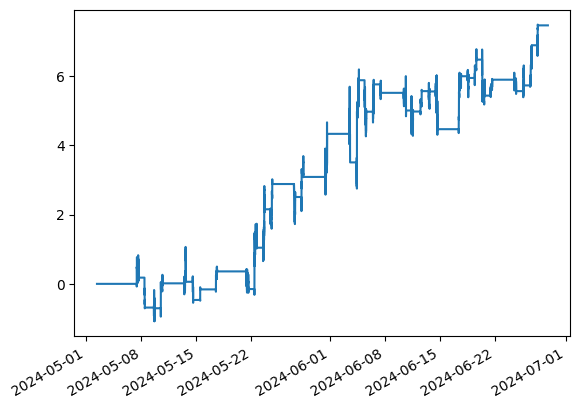

In [30]:
xx.plot()

In [31]:
#df[0:50]

In [32]:
xx[-1:]

2024-06-28 17:59:45    7.47
dtype: float64

# OOT part - July, Aug

## Data preparation

In [33]:
data_lead = pd.read_parquet(r's:\Algo\Files\andrej\Data\int_data_lead_dem1_jul_aug.parquet', engine='fastparquet').reset_index()
data_lag = pd.read_parquet(r's:\Algo\Files\andrej\Data\int_data_lag_dem2_jul_aug.parquet', engine='fastparquet').reset_index()

In [34]:
data_lead['datetime']=pd.to_datetime(data_lead['datetime'], format='mixed')
data_lag['datetime']=pd.to_datetime(data_lag['datetime'], format='mixed')

In [35]:
data_lag['time_diff']=data_lag['datetime'].diff().dt.total_seconds().fillna(0)

In [36]:
data_lead=data_lead[data_lead['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]
data_lag=data_lag[data_lag['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]

In [37]:
#data_lag=data_lag.drop(index=177223).reset_index()
del data_lag['level_0']
del data_lead['level_0']

In [38]:
data_lag.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side,time_diff
469,469,2024-07-01 09:00:06.000000000,NaN,NaN,84.57,85.59,85.08,1.0,7.000000
470,470,2024-07-01 09:00:07.000000000,NaN,NaN,84.59,85.59,85.09,1.0,1.000000
471,471,2024-07-01 09:00:08.673907280,85.59,2.0,84.59,85.59,85.09,1.0,1.673907
472,472,2024-07-01 09:00:09.000000000,NaN,NaN,84.61,85.59,85.10,1.0,0.326093
473,473,2024-07-01 09:00:10.124257326,85.59,1.0,84.61,85.59,85.10,1.0,1.124257


In [39]:
data_lead.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side
123,123,2024-07-01 09:00:05.687479496,77.78,1.0,76.90,77.78,77.34,1.0
124,124,2024-07-01 09:00:10.607145071,77.78,1.0,77.00,77.78,77.39,1.0
125,125,2024-07-01 09:00:21.248078108,77.87,8.0,77.17,77.87,77.52,1.0
126,126,2024-07-01 09:01:07.907927752,77.93,6.0,77.51,77.93,77.72,1.0
127,127,2024-07-01 09:01:07.907927752,77.95,1.0,77.51,77.93,77.72,1.0


## Parameters and calculations

In [40]:
instr = 'm2'

contr_vars = []

param_list = ['t_end', 'take_profit', 'stop_loss']
param_dict = {k: [] for k in param_list}
param_dict['t_end'] = time(17)
param_dict['take_profit'] = take_profit
param_dict['stop_loss'] = stop_loss
param_dict['ba_max']=0.3
param_dict['aggloss_thres']=aggloss_thres

param_dict['br_fee'] = br_fee

param_dict['MACD_long_threshold'] = MACD_long_threshold
param_dict['MACD_short_threshold'] = MACD_short_threshold
param_dict['price_diff_long_threshold'] = price_diff_long_threshold
param_dict['price_diff_short_threshold'] = price_diff_short_threshold

param_dict['combined_long_threshold'] = combined_long_threshold
param_dict['combined_short_threshold'] = combined_short_threshold

param_dict['minimum_intensity'] = minimum_intensity

param_dict['burnout_period']=burnout_period
param_dict['stop_profit']=stop_profit
param_dict['makeagg_ratio']=makeagg_ratio
param_dict['trail_stop']=trail_stop

param_dict['combined_mode'] = combined_mode

param_dict['fit_reg_coef'] = fit_reg_coef
param_dict['coef1'] = coef1
param_dict['coef2'] = coef2



vol_class = VolumeClass(1, {'max_clips': 1})
backtest_class = BacktestLL(vol_class)
# model_class = HawkesIntensity
strategy_class = StrategyLL(
                            strategy='LL',
                            market='de',
                            instrument=instr, 
                            is_overnight=False,
                            closing_mode=closing_mode)

strategy_class.load_params(param_dict, contr_vars)

xx = backtest_class.simulate_strategy(strategy_class, instr, data_lag, data_lead)

df = pd.DataFrame({k: strategy_class.stats_dict[k] for k in list(strategy_class.stats_dict.keys()) if k in ['timestamp', 'position', 'price_level']})
df = pd.concat([df, ])

## Results

In [41]:
# from bokeh.plotting import figure, show, output_file
# from bokeh.models import ColumnDataSource, Range1d, LinearAxis, HoverTool
# import pandas as pd

# # Assuming 'data_lag', 'data_lead', and 'df' are already defined as per your context

# # Convert 'timestamp' to datetime if not already
# df['timestamp'] = pd.to_datetime(df['timestamp'])

# # Assign color based on 'position' value
# df['color'] = df['position'].map({1: 'green', -1: 'red', 0: 'black'})
# df['price_level']=df['price_level']-df['position']*br_fee

# # Create ColumnDataSources
# source_df = ColumnDataSource(df)
# source_lead = ColumnDataSource(data_lead)
# source_lag = ColumnDataSource(data_lag)

# # Create a figure with dynamic sizing
# p = figure(x_axis_type="datetime", title="Strategy Positions", sizing_mode='stretch_both')

# # Adjust y-axes ranges
# p.extra_y_ranges = {
#    "Lead price": Range1d(start=data_lead['trd_price'].min(), end=data_lead['trd_price'].max()),
#    "Lag price": Range1d(start=data_lag['trd_price'].min(), end=data_lag['trd_price'].max())
# }

# # Add left and right y-axes
# p.add_layout(LinearAxis(y_range_name="Lead price", axis_label="Lead Price"), 'left')
# p.add_layout(LinearAxis(y_range_name="Lag price", axis_label="Lag Price"), 'right')

# # Plotting with hover tools
# lead_crosses = p.cross(x='datetime', y='trd_price', source=source_lead, size=10, color='blue', legend_label="Lead Price", y_range_name="Lead price")
# lag_crosses = p.cross(x='datetime', y='trd_price', source=source_lag, size=10, color='orange', legend_label="Lag Price", y_range_name="Lag price")
# position_circles = p.circle(x='timestamp', y='price_level', source=source_df, size=10, color='color', legend_label="Position", y_range_name="Lag price")

# # Define hover tools for each glyph
# hover_position = HoverTool(renderers=[position_circles], tooltips=[
#     ("Timestamp", "@timestamp{%F %T}"),
#     ("Price Level", "@price_level"),
#     ("Position", "@position"),
#     ("Color", "@color"),
# ], formatters={'@timestamp': 'datetime'})

# hover_lead = HoverTool(renderers=[lead_crosses], tooltips=[
#     ("Datetime", "@datetime{%F %T}"),
#     ("Lead Price", "@trd_price"),
# ], formatters={'@datetime': 'datetime'})

# hover_lag = HoverTool(renderers=[lag_crosses], tooltips=[
#     ("Datetime", "@datetime{%F %T}"),
#     ("Lag Price", "@trd_price"),
# ], formatters={'@datetime': 'datetime'})

# # Add hover tools to the plot
# p.add_tools(hover_position, hover_lead, hover_lag)

# # Customize plot
# p.legend.location = "top_left"
# p.xaxis.axis_label = "Datetime"
# p.yaxis.axis_label = "Price Level"

# # Show the plot
# show(p)

<Axes: >

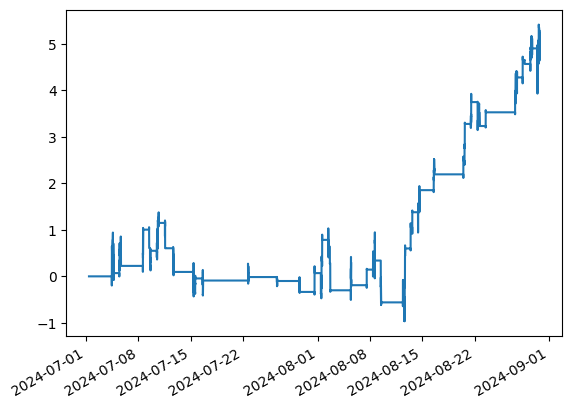

In [42]:
xx.plot()

In [43]:
#df[0:50]

In [44]:
xx[-1:]

2024-08-30 17:59:50.029918909    4.685
dtype: float64

# OOT part - Sep, Oct

## Data preparation

In [45]:
data_lead = pd.read_parquet(r's:\Algo\Files\andrej\Data\int_data_lead_dem1_sep_oct.parquet', engine='fastparquet').reset_index()
data_lag = pd.read_parquet(r's:\Algo\Files\andrej\Data\int_data_lag_dem2_sep_oct.parquet', engine='fastparquet').reset_index()

In [46]:
data_lead['datetime']=pd.to_datetime(data_lead['datetime'], format='mixed')
data_lag['datetime']=pd.to_datetime(data_lag['datetime'], format='mixed')

In [47]:
data_lag['time_diff']=data_lag['datetime'].diff().dt.total_seconds().fillna(0)

In [48]:
data_lead=data_lead[data_lead['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]
data_lag=data_lag[data_lag['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]

In [49]:
#data_lag=data_lag.drop(index=177223).reset_index()
del data_lag['level_0']
del data_lead['level_0']

In [50]:
data_lag.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side,time_diff
1889,1889,2024-09-02 09:00:00.017744303,101.86,1.0,101.86,102.0,101.93,-1.0,0.823274
1890,1890,2024-09-02 09:00:03.019105434,101.87,1.0,101.86,102.0,101.93,-1.0,3.001361
1891,1891,2024-09-02 09:00:03.019105434,101.86,1.0,101.86,102.0,101.93,-1.0,0.000000
1892,1892,2024-09-02 09:00:03.310868263,101.86,1.0,101.86,102.0,101.93,-1.0,0.291763
1893,1893,2024-09-02 09:00:03.321099758,101.86,1.0,101.86,102.0,101.93,-1.0,0.010231


In [51]:
data_lead.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side
356,356,2024-09-02 09:00:00.374863148,91.10,1.0,91.01,91.09,91.050,1.0
357,357,2024-09-02 09:00:00.396098137,91.10,2.0,91.01,91.09,91.050,1.0
358,358,2024-09-02 09:00:00.475012779,91.09,1.0,91.01,91.09,91.050,1.0
359,359,2024-09-02 09:00:00.475463152,91.10,2.0,91.01,91.09,91.050,1.0
360,360,2024-09-02 09:01:00.238040686,91.10,1.0,91.01,91.10,91.055,1.0


## Parameters and calculations

In [52]:
instr = 'm2'

contr_vars = []

param_list = ['t_end', 'take_profit', 'stop_loss']
param_dict = {k: [] for k in param_list}
param_dict['t_end'] = time(17)
param_dict['take_profit'] = take_profit
param_dict['stop_loss'] = stop_loss
param_dict['ba_max']=0.3
param_dict['aggloss_thres']=aggloss_thres

param_dict['br_fee'] = br_fee

param_dict['MACD_long_threshold'] = MACD_long_threshold
param_dict['MACD_short_threshold'] = MACD_short_threshold
param_dict['price_diff_long_threshold'] = price_diff_long_threshold
param_dict['price_diff_short_threshold'] = price_diff_short_threshold

param_dict['combined_long_threshold'] = combined_long_threshold
param_dict['combined_short_threshold'] = combined_short_threshold

param_dict['minimum_intensity'] = minimum_intensity

param_dict['burnout_period']=burnout_period
param_dict['stop_profit']=stop_profit
param_dict['makeagg_ratio']=makeagg_ratio
param_dict['trail_stop']=trail_stop

param_dict['combined_mode'] = combined_mode

param_dict['fit_reg_coef'] = fit_reg_coef
param_dict['coef1'] = coef1
param_dict['coef2'] = coef2



vol_class = VolumeClass(1, {'max_clips': 1})
backtest_class = BacktestLL(vol_class)
# model_class = HawkesIntensity
strategy_class = StrategyLL(
                            strategy='LL',
                            market='de',
                            instrument=instr, 
                            is_overnight=False,
                            closing_mode=closing_mode)

strategy_class.load_params(param_dict, contr_vars)

xx = backtest_class.simulate_strategy(strategy_class, instr, data_lag, data_lead)

df = pd.DataFrame({k: strategy_class.stats_dict[k] for k in list(strategy_class.stats_dict.keys()) if k in ['timestamp', 'position', 'price_level']})
df = pd.concat([df, ])

## Results

In [53]:
# from bokeh.plotting import figure, show, output_file
# from bokeh.models import ColumnDataSource, Range1d, LinearAxis, HoverTool
# import pandas as pd

# # Assuming 'data_lag', 'data_lead', and 'df' are already defined as per your context

# # Convert 'timestamp' to datetime if not already
# df['timestamp'] = pd.to_datetime(df['timestamp'])

# # Assign color based on 'position' value
# df['color'] = df['position'].map({1: 'green', -1: 'red', 0: 'black'})
# df['price_level']=df['price_level']-df['position']*br_fee

# # Create ColumnDataSources
# source_df = ColumnDataSource(df)
# source_lead = ColumnDataSource(data_lead)
# source_lag = ColumnDataSource(data_lag)

# # Create a figure with dynamic sizing
# p = figure(x_axis_type="datetime", title="Strategy Positions", sizing_mode='stretch_both')

# # Adjust y-axes ranges
# p.extra_y_ranges = {
#    "Lead price": Range1d(start=data_lead['trd_price'].min(), end=data_lead['trd_price'].max()),
#    "Lag price": Range1d(start=data_lag['trd_price'].min(), end=data_lag['trd_price'].max())
# }

# # Add left and right y-axes
# p.add_layout(LinearAxis(y_range_name="Lead price", axis_label="Lead Price"), 'left')
# p.add_layout(LinearAxis(y_range_name="Lag price", axis_label="Lag Price"), 'right')

# # Plotting with hover tools
# lead_crosses = p.cross(x='datetime', y='trd_price', source=source_lead, size=10, color='blue', legend_label="Lead Price", y_range_name="Lead price")
# lag_crosses = p.cross(x='datetime', y='trd_price', source=source_lag, size=10, color='orange', legend_label="Lag Price", y_range_name="Lag price")
# position_circles = p.circle(x='timestamp', y='price_level', source=source_df, size=10, color='color', legend_label="Position", y_range_name="Lag price")

# # Define hover tools for each glyph
# hover_position = HoverTool(renderers=[position_circles], tooltips=[
#     ("Timestamp", "@timestamp{%F %T}"),
#     ("Price Level", "@price_level"),
#     ("Position", "@position"),
#     ("Color", "@color"),
# ], formatters={'@timestamp': 'datetime'})

# hover_lead = HoverTool(renderers=[lead_crosses], tooltips=[
#     ("Datetime", "@datetime{%F %T}"),
#     ("Lead Price", "@trd_price"),
# ], formatters={'@datetime': 'datetime'})

# hover_lag = HoverTool(renderers=[lag_crosses], tooltips=[
#     ("Datetime", "@datetime{%F %T}"),
#     ("Lag Price", "@trd_price"),
# ], formatters={'@datetime': 'datetime'})

# # Add hover tools to the plot
# p.add_tools(hover_position, hover_lead, hover_lag)

# # Customize plot
# p.legend.location = "top_left"
# p.xaxis.axis_label = "Datetime"
# p.yaxis.axis_label = "Price Level"

# # Show the plot
# show(p)

<Axes: >

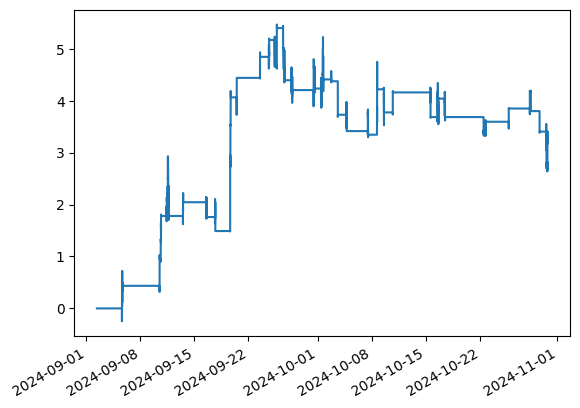

In [54]:
xx.plot()

In [55]:
#df[0:50]

In [56]:
xx[-1:]

2024-10-30 17:59:53.296451807    3.18
dtype: float64

# OOT part - Nov, Dec

## Data preparation

In [57]:
data_lead = pd.read_parquet(r's:\Algo\Files\andrej\Data\int_data_lead_dem1_nov_dec.parquet', engine='fastparquet').reset_index()
data_lag = pd.read_parquet(r's:\Algo\Files\andrej\Data\int_data_lag_dem2_nov_dec.parquet', engine='fastparquet').reset_index()

In [58]:
data_lead['datetime']=pd.to_datetime(data_lead['datetime'], format='mixed')
data_lag['datetime']=pd.to_datetime(data_lag['datetime'], format='mixed')

In [59]:
data_lag['time_diff']=data_lag['datetime'].diff().dt.total_seconds().fillna(0)

In [60]:
data_lead=data_lead[data_lead['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]
data_lag=data_lag[data_lag['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]

In [61]:
#data_lag=data_lag.drop(index=177223).reset_index()
del data_lag['level_0']
del data_lead['level_0']

In [62]:
data_lag.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side,time_diff
562,562,2024-11-01 09:00:25,NaN,NaN,95.73,96.24,95.985,NaN,136.0
563,563,2024-11-01 09:00:26,NaN,NaN,95.75,96.24,95.995,NaN,1.0
564,564,2024-11-01 09:00:33,NaN,NaN,95.77,96.24,96.005,NaN,7.0
565,565,2024-11-01 09:00:35,NaN,NaN,95.79,96.24,96.015,NaN,2.0
566,566,2024-11-01 09:00:40,NaN,NaN,95.82,96.24,96.030,NaN,5.0


In [63]:
data_lead.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side
281,281,2024-11-01 09:00:14.356941938,86.30,1.0,86.02,86.3,86.16,1.0
282,282,2024-11-01 09:00:14.439558506,86.30,1.0,86.02,86.3,86.16,1.0
283,283,2024-11-01 09:00:24.800893545,86.30,1.0,86.02,86.3,86.16,1.0
284,284,2024-11-01 09:00:24.811118126,86.35,1.0,86.02,86.3,86.16,1.0
285,285,2024-11-01 09:00:24.813110113,86.30,1.0,86.02,86.3,86.16,1.0


## Parameters and calculations

In [64]:
instr = 'm2'

contr_vars = []

param_list = ['t_end', 'take_profit', 'stop_loss']
param_dict = {k: [] for k in param_list}
param_dict['t_end'] = time(17)
param_dict['take_profit'] = take_profit
param_dict['stop_loss'] = stop_loss
param_dict['ba_max']=0.3
param_dict['aggloss_thres']=aggloss_thres

param_dict['br_fee'] = br_fee

param_dict['MACD_long_threshold'] = MACD_long_threshold
param_dict['MACD_short_threshold'] = MACD_short_threshold
param_dict['price_diff_long_threshold'] = price_diff_long_threshold
param_dict['price_diff_short_threshold'] = price_diff_short_threshold

param_dict['combined_long_threshold'] = combined_long_threshold
param_dict['combined_short_threshold'] = combined_short_threshold

param_dict['minimum_intensity'] = minimum_intensity

param_dict['burnout_period']=burnout_period
param_dict['stop_profit']=stop_profit
param_dict['makeagg_ratio']=makeagg_ratio
param_dict['trail_stop']=trail_stop

param_dict['combined_mode'] = combined_mode

param_dict['fit_reg_coef'] = fit_reg_coef
param_dict['coef1'] = coef1
param_dict['coef2'] = coef2



vol_class = VolumeClass(1, {'max_clips': 1})
backtest_class = BacktestLL(vol_class)
# model_class = HawkesIntensity
strategy_class = StrategyLL(
                            strategy='LL',
                            market='de',
                            instrument=instr, 
                            is_overnight=False,
                            closing_mode=closing_mode)

strategy_class.load_params(param_dict, contr_vars)

xx = backtest_class.simulate_strategy(strategy_class, instr, data_lag, data_lead)

df = pd.DataFrame({k: strategy_class.stats_dict[k] for k in list(strategy_class.stats_dict.keys()) if k in ['timestamp', 'position', 'price_level']})
df = pd.concat([df, ])

## Results

In [65]:
# from bokeh.plotting import figure, show, output_file
# from bokeh.models import ColumnDataSource, Range1d, LinearAxis, HoverTool
# import pandas as pd

# # Assuming 'data_lag', 'data_lead', and 'df' are already defined as per your context

# # Convert 'timestamp' to datetime if not already
# df['timestamp'] = pd.to_datetime(df['timestamp'])

# # Assign color based on 'position' value
# df['color'] = df['position'].map({1: 'green', -1: 'red', 0: 'black'})
# df['price_level']=df['price_level']-df['position']*br_fee

# # Create ColumnDataSources
# source_df = ColumnDataSource(df)
# source_lead = ColumnDataSource(data_lead)
# source_lag = ColumnDataSource(data_lag)

# # Create a figure with dynamic sizing
# p = figure(x_axis_type="datetime", title="Strategy Positions", sizing_mode='stretch_both')

# # Adjust y-axes ranges
# p.extra_y_ranges = {
#    "Lead price": Range1d(start=data_lead['trd_price'].min(), end=data_lead['trd_price'].max()),
#    "Lag price": Range1d(start=data_lag['trd_price'].min(), end=data_lag['trd_price'].max())
# }

# # Add left and right y-axes
# p.add_layout(LinearAxis(y_range_name="Lead price", axis_label="Lead Price"), 'left')
# p.add_layout(LinearAxis(y_range_name="Lag price", axis_label="Lag Price"), 'right')

# # Plotting with hover tools
# lead_crosses = p.cross(x='datetime', y='trd_price', source=source_lead, size=10, color='blue', legend_label="Lead Price", y_range_name="Lead price")
# lag_crosses = p.cross(x='datetime', y='trd_price', source=source_lag, size=10, color='orange', legend_label="Lag Price", y_range_name="Lag price")
# position_circles = p.circle(x='timestamp', y='price_level', source=source_df, size=10, color='color', legend_label="Position", y_range_name="Lag price")

# # Define hover tools for each glyph
# hover_position = HoverTool(renderers=[position_circles], tooltips=[
#     ("Timestamp", "@timestamp{%F %T}"),
#     ("Price Level", "@price_level"),
#     ("Position", "@position"),
#     ("Color", "@color"),
# ], formatters={'@timestamp': 'datetime'})

# hover_lead = HoverTool(renderers=[lead_crosses], tooltips=[
#     ("Datetime", "@datetime{%F %T}"),
#     ("Lead Price", "@trd_price"),
# ], formatters={'@datetime': 'datetime'})

# hover_lag = HoverTool(renderers=[lag_crosses], tooltips=[
#     ("Datetime", "@datetime{%F %T}"),
#     ("Lag Price", "@trd_price"),
# ], formatters={'@datetime': 'datetime'})

# # Add hover tools to the plot
# p.add_tools(hover_position, hover_lead, hover_lag)

# # Customize plot
# p.legend.location = "top_left"
# p.xaxis.axis_label = "Datetime"
# p.yaxis.axis_label = "Price Level"

# # Show the plot
# show(p)

<Axes: >

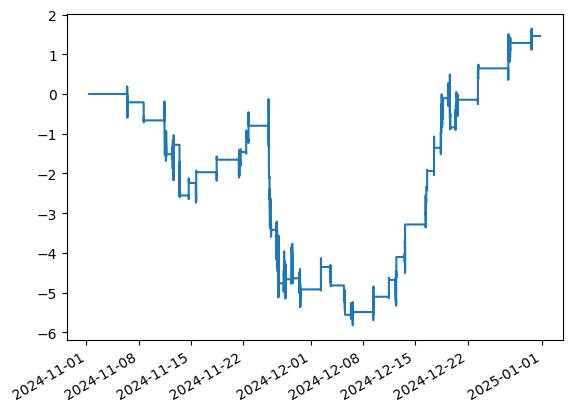

In [66]:
xx.plot()

In [67]:
#df[0:50]

In [68]:
xx[-1:]

2024-12-31 17:01:57    1.46
dtype: float64

# OOT part - Jan, Feb

## Data preparation

In [69]:
data_lead = pd.read_parquet(r's:\Algo\Files\andrej\Data\int_data_lead_dem1_jan_feb_2025.parquet', engine='fastparquet').reset_index()
data_lag = pd.read_parquet(r's:\Algo\Files\andrej\Data\int_data_lag_dem2_jan_feb_2025.parquet', engine='fastparquet').reset_index()

In [70]:
data_lead['datetime']=pd.to_datetime(data_lead['datetime'], format='mixed')
data_lag['datetime']=pd.to_datetime(data_lag['datetime'], format='mixed')

In [71]:
data_lag['time_diff']=data_lag['datetime'].diff().dt.total_seconds().fillna(0)

In [72]:
data_lead=data_lead[data_lead['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]
data_lag=data_lag[data_lag['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]

In [73]:
#data_lag=data_lag.drop(index=177223).reset_index()
del data_lag['level_0']
del data_lead['level_0']

In [74]:
data_lag.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side,time_diff
1377,1377,2025-01-02 09:00:11,NaN,NaN,97.71,97.90,97.805,NaN,19.0
1378,1378,2025-01-02 09:00:16,NaN,NaN,97.71,97.88,97.795,NaN,5.0
1379,1379,2025-01-02 09:00:17,NaN,NaN,97.71,97.90,97.805,NaN,1.0
1380,1380,2025-01-02 09:00:18,NaN,NaN,97.69,97.90,97.795,NaN,1.0
1381,1381,2025-01-02 09:00:27,NaN,NaN,97.69,97.94,97.815,NaN,9.0


In [75]:
data_lead.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side
202,202,2025-01-02 09:01:18.449423552,115.36,1.0,115.30,115.36,115.330,1.0
203,203,2025-01-02 09:01:59.860338449,115.43,1.0,115.07,115.43,115.250,1.0
204,204,2025-01-02 09:02:32.845537186,115.40,1.0,115.07,115.40,115.235,1.0
205,205,2025-01-02 09:03:38.814864397,115.39,1.0,115.07,115.41,115.240,1.0
206,206,2025-01-02 09:04:11.800163507,115.40,1.0,115.07,115.40,115.235,1.0


## Parameters and calculations

In [76]:
instr = 'm2'

contr_vars = []

param_list = ['t_end', 'take_profit', 'stop_loss']
param_dict = {k: [] for k in param_list}
param_dict['t_end'] = time(17)
param_dict['take_profit'] = take_profit
param_dict['stop_loss'] = stop_loss
param_dict['ba_max']=0.3
param_dict['aggloss_thres']=aggloss_thres

param_dict['br_fee'] = br_fee

param_dict['MACD_long_threshold'] = MACD_long_threshold
param_dict['MACD_short_threshold'] = MACD_short_threshold
param_dict['price_diff_long_threshold'] = price_diff_long_threshold
param_dict['price_diff_short_threshold'] = price_diff_short_threshold

param_dict['combined_long_threshold'] = combined_long_threshold
param_dict['combined_short_threshold'] = combined_short_threshold

param_dict['minimum_intensity'] = minimum_intensity

param_dict['burnout_period']=burnout_period
param_dict['stop_profit']=stop_profit
param_dict['makeagg_ratio']=makeagg_ratio
param_dict['trail_stop']=trail_stop

param_dict['combined_mode'] = combined_mode

param_dict['fit_reg_coef'] = fit_reg_coef
param_dict['coef1'] = coef1
param_dict['coef2'] = coef2



vol_class = VolumeClass(1, {'max_clips': 1})
backtest_class = BacktestLL(vol_class)
# model_class = HawkesIntensity
strategy_class = StrategyLL(
                            strategy='LL',
                            market='de',
                            instrument=instr, 
                            is_overnight=False,
                            closing_mode=closing_mode)

strategy_class.load_params(param_dict, contr_vars)

xx = backtest_class.simulate_strategy(strategy_class, instr, data_lag, data_lead)

df = pd.DataFrame({k: strategy_class.stats_dict[k] for k in list(strategy_class.stats_dict.keys()) if k in ['timestamp', 'position', 'price_level']})
df = pd.concat([df, ])

## Results

In [77]:
# from bokeh.plotting import figure, show, output_file
# from bokeh.models import ColumnDataSource, Range1d, LinearAxis, HoverTool
# import pandas as pd

# # Assuming 'data_lag', 'data_lead', and 'df' are already defined as per your context

# # Convert 'timestamp' to datetime if not already
# df['timestamp'] = pd.to_datetime(df['timestamp'])

# # Assign color based on 'position' value
# df['color'] = df['position'].map({1: 'green', -1: 'red', 0: 'black'})
# df['price_level']=df['price_level']-df['position']*br_fee

# # Create ColumnDataSources
# source_df = ColumnDataSource(df)
# source_lead = ColumnDataSource(data_lead)
# source_lag = ColumnDataSource(data_lag)

# # Create a figure with dynamic sizing
# p = figure(x_axis_type="datetime", title="Strategy Positions", sizing_mode='stretch_both')

# # Adjust y-axes ranges
# p.extra_y_ranges = {
#    "Lead price": Range1d(start=data_lead['trd_price'].min(), end=data_lead['trd_price'].max()),
#    "Lag price": Range1d(start=data_lag['trd_price'].min(), end=data_lag['trd_price'].max())
# }

# # Add left and right y-axes
# p.add_layout(LinearAxis(y_range_name="Lead price", axis_label="Lead Price"), 'left')
# p.add_layout(LinearAxis(y_range_name="Lag price", axis_label="Lag Price"), 'right')

# # Plotting with hover tools
# lead_crosses = p.cross(x='datetime', y='trd_price', source=source_lead, size=10, color='blue', legend_label="Lead Price", y_range_name="Lead price")
# lag_crosses = p.cross(x='datetime', y='trd_price', source=source_lag, size=10, color='orange', legend_label="Lag Price", y_range_name="Lag price")
# position_circles = p.circle(x='timestamp', y='price_level', source=source_df, size=10, color='color', legend_label="Position", y_range_name="Lag price")

# # Define hover tools for each glyph
# hover_position = HoverTool(renderers=[position_circles], tooltips=[
#     ("Timestamp", "@timestamp{%F %T}"),
#     ("Price Level", "@price_level"),
#     ("Position", "@position"),
#     ("Color", "@color"),
# ], formatters={'@timestamp': 'datetime'})

# hover_lead = HoverTool(renderers=[lead_crosses], tooltips=[
#     ("Datetime", "@datetime{%F %T}"),
#     ("Lead Price", "@trd_price"),
# ], formatters={'@datetime': 'datetime'})

# hover_lag = HoverTool(renderers=[lag_crosses], tooltips=[
#     ("Datetime", "@datetime{%F %T}"),
#     ("Lag Price", "@trd_price"),
# ], formatters={'@datetime': 'datetime'})

# # Add hover tools to the plot
# p.add_tools(hover_position, hover_lead, hover_lag)

# # Customize plot
# p.legend.location = "top_left"
# p.xaxis.axis_label = "Datetime"
# p.yaxis.axis_label = "Price Level"

# # Show the plot
# show(p)

<Axes: >

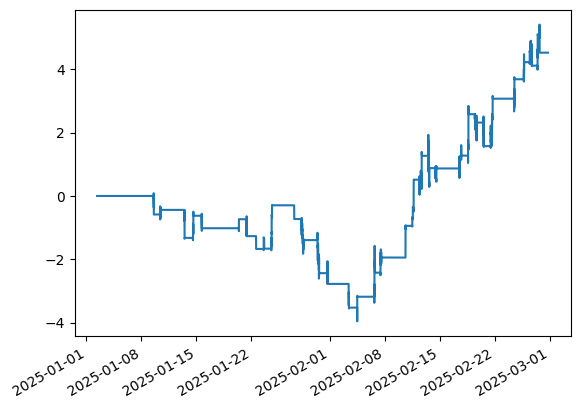

In [78]:
xx.plot()

In [79]:
#df[0:50]

In [80]:
xx[-1:]

2025-02-28 17:59:56    4.53
dtype: float64

# Production check

## Data preparation

In [31]:
data_lead = pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lead_production_sample.csv',
                    parse_dates=['datetime']).reset_index()

data_lag = pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lag_production_sample.csv',
                    parse_dates=['datetime']).reset_index()

In [32]:
data_lead['datetime'] = pd.to_datetime(data_lead['datetime'], errors='coerce')
data_lag['datetime'] = pd.to_datetime(data_lag['datetime'], errors='coerce')

In [33]:
data_lag['time_diff']=data_lag['datetime'].diff().dt.total_seconds().fillna(0)

In [34]:
data_lead=data_lead[data_lead['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]
data_lag=data_lag[data_lag['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]

In [35]:
# data_lag=data_lag.drop(index=177223).reset_index()
# del data_lag['level_0']

In [36]:
data_lag.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side,time_diff
732,732,2025-02-26 09:00:10.808141232,79.5,1.0,NaN,79.56,79.560,-1.0,11.808141
733,733,2025-02-26 09:00:10.848340750,79.5,1.0,NaN,79.56,79.560,-1.0,0.040200
734,734,2025-02-26 09:00:11.000000000,NaN,NaN,79.41,79.50,79.455,NaN,0.151659
735,735,2025-02-26 09:00:15.532733679,79.5,1.0,NaN,79.50,79.500,NaN,4.532734
736,736,2025-02-26 09:00:15.543951511,79.5,1.0,NaN,79.50,79.500,NaN,0.011218


In [37]:
data_lead.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side
199,199,2025-02-26 09:00:05.312807083,92.76,1.0,NaN,93.00,93.00,-1.0
200,200,2025-02-26 09:01:25.509067774,92.83,2.0,NaN,92.95,92.95,-1.0
201,201,2025-02-26 09:01:25.509189605,92.80,1.0,NaN,92.95,92.95,-1.0
202,202,2025-02-26 09:01:25.527140379,92.80,1.0,NaN,92.95,92.95,-1.0
203,203,2025-02-26 09:01:25.538492203,92.80,1.0,NaN,92.95,92.95,-1.0


## Parameters and calculations

In [38]:
instr = 'm2'

contr_vars = []

param_list = ['t_end', 'take_profit', 'stop_loss']
param_dict = {k: [] for k in param_list}
param_dict['t_end'] = time(17)
param_dict['take_profit'] = take_profit
param_dict['stop_loss'] = stop_loss
param_dict['ba_max']=0.3
param_dict['aggloss_thres']=aggloss_thres

param_dict['br_fee'] = br_fee

param_dict['MACD_long_threshold'] = MACD_long_threshold
param_dict['MACD_short_threshold'] = MACD_short_threshold
param_dict['price_diff_long_threshold'] = price_diff_long_threshold
param_dict['price_diff_short_threshold'] = price_diff_short_threshold

param_dict['combined_long_threshold'] = combined_long_threshold
param_dict['combined_short_threshold'] = combined_short_threshold

param_dict['minimum_intensity'] = minimum_intensity

param_dict['burnout_period']=burnout_period
param_dict['stop_profit']=stop_profit
param_dict['makeagg_ratio']=makeagg_ratio
param_dict['trail_stop']=trail_stop

param_dict['combined_mode'] = combined_mode

param_dict['fit_reg_coef'] = fit_reg_coef
param_dict['coef1'] = coef1
param_dict['coef2'] = coef2



vol_class = VolumeClass(1, {'max_clips': 1})
backtest_class = BacktestLL(vol_class)
# model_class = HawkesIntensity
strategy_class = StrategyLL(
                            strategy='LL',
                            market='de',
                            instrument=instr, 
                            is_overnight=False,
                            closing_mode=closing_mode)

strategy_class.load_params(param_dict, contr_vars)

xx = backtest_class.simulate_strategy(strategy_class, instr, data_lag, data_lead)

df = pd.DataFrame({k: strategy_class.stats_dict[k] for k in list(strategy_class.stats_dict.keys()) if k in ['timestamp', 'position', 'price_level']})
df = pd.concat([df, ])

Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko


## Results

In [39]:
from bokeh.plotting import figure, show, output_file
from bokeh.models import ColumnDataSource, Range1d, LinearAxis, HoverTool
import pandas as pd

# As

# Assign color based on 'position' value
df['color'] = df['position'].map({1: 'green', -1: 'red', 0: 'black'})
df['price_level']=df['price_level']-df['position']*br_fee

# Create ColumnDataSources
source_df = ColumnDataSource(df)
source_lead = ColumnDataSource(data_lead)
source_lag = ColumnDataSource(data_lag)

# Create a figure with dynamic sizing
p = figure(x_axis_type="datetime", title="Strategy Positions", sizing_mode='stretch_both')

# Adjust y-axes ranges
p.extra_y_ranges = {
   "Lead price": Range1d(start=data_lead['trd_price'].min(), end=data_lead['trd_price'].max()),
   "Lag price": Range1d(start=data_lag['trd_price'].min(), end=data_lag['trd_price'].max())
}

# Add left and right y-axes
p.add_layout(LinearAxis(y_range_name="Lead price", axis_label="Lead Price"), 'left')
p.add_layout(LinearAxis(y_range_name="Lag price", axis_label="Lag Price"), 'right')

# Plotting with hover tools
lead_crosses = p.cross(x='datetime', y='trd_price', source=source_lead, size=10, color='blue', legend_label="Lead Price", y_range_name="Lead price")
lag_crosses = p.cross(x='datetime', y='trd_price', source=source_lag, size=10, color='orange', legend_label="Lag Price", y_range_name="Lag price")
position_circles = p.circle(x='timestamp', y='price_level', source=source_df, size=10, color='color', legend_label="Position", y_range_name="Lag price")

# Define hover tools for each glyph
hover_position = HoverTool(renderers=[position_circles], tooltips=[
    ("Timestamp", "@timestamp{%F %T}"),
    ("Price Level", "@price_level"),
    ("Position", "@position"),
    ("Color", "@color"),
], formatters={'@timestamp': 'datetime'})

hover_lead = HoverTool(renderers=[lead_crosses], tooltips=[
    ("Datetime", "@datetime{%F %T}"),
    ("Lead Price", "@trd_price"),
], formatters={'@datetime': 'datetime'})

hover_lag = HoverTool(renderers=[lag_crosses], tooltips=[
    ("Datetime", "@datetime{%F %T}"),
    ("Lag Price", "@trd_price"),
], formatters={'@datetime': 'datetime'})

# Add hover tools to the plot
p.add_tools(hover_position, hover_lead, hover_lag)

# Customize plot
p.legend.location = "top_left"
p.xaxis.axis_label = "Datetime"
p.yaxis.axis_label = "Price Level"

# Show the plot
show(p)

<Axes: >

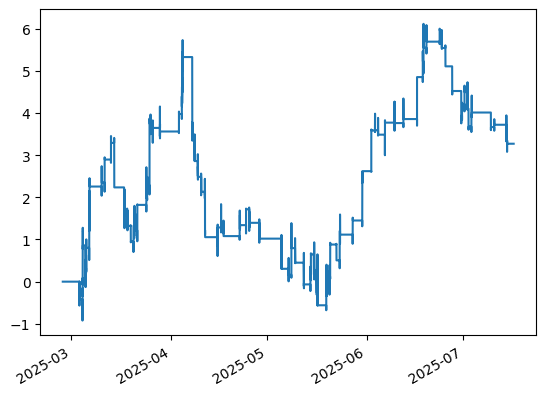

In [40]:
xx.plot()

In [41]:
#df[0:50]

In [42]:
xx[-1:]

2025-07-16 17:59:40    3.27
dtype: float64

In [43]:
# xx

In [44]:

# xx1.reset_index()

In [45]:
# start_time = '2024-06-20 10:27:04'
# end_time = '2024-06-20 10:27:09'

# a=df_ba_data1.reset_index()

# a[(a['timestamp'] >= start_time) & (a['timestamp'] <= end_time)]

In [46]:
# df=data_class.get_orders_data(mkt, tenor, venue_list, start_date1,
#                                           bT, eT, prod, start_date2)

In [47]:
# start_time = '2024-06-19 16:52:00'
# end_time = '2024-06-19 16:54:00'

# a=df.reset_index()

# type(a[(a['timestamp'] >= start_time) & (a['timestamp'] <= end_time)]['bids'][31920][0])

In [48]:
# start_time = '2024-06-19 16:52:00'
# end_time = '2024-06-19 16:54:00'

# ob_class.LoB_dict[130000].bids[1].po_id

# All periods

## Data preparation

In [12]:
data_lead =pd.concat([pd.read_parquet(r's:\Algo\Files\andrej\Data\int_data_lead_dem1_jan_feb_2025.parquet'
                    ).reset_index(), pd.read_parquet(r's:\Algo\Files\andrej\Data\int_data_lead_dem1_mar_apr.parquet'
                    ).reset_index(), pd.read_parquet(r's:\Algo\Files\andrej\Data\int_data_lead_dem1_may_june.parquet'
                    ).reset_index(), pd.read_parquet(r's:\Algo\Files\andrej\Data\int_data_lead_dem1_jul_aug.parquet'
                    ).reset_index(), pd.read_parquet(r's:\Algo\Files\andrej\Data\int_data_lead_dem1_sep_oct.parquet'  
                    ).reset_index(), pd.read_parquet(r's:\Algo\Files\andrej\Data\int_data_lead_dem1_nov_dec.parquet'        
                    ).reset_index()])

data_lag=pd.concat([pd.read_parquet(r's:\Algo\Files\andrej\Data\int_data_lag_dem2_jan_feb_2025.parquet'
                    ).reset_index(), pd.read_parquet(r's:\Algo\Files\andrej\Data\int_data_lag_dem2_mar_apr.parquet'
                    ).reset_index(), pd.read_parquet(r's:\Algo\Files\andrej\Data\int_data_lag_dem2_may_june.parquet'
                    ).reset_index(), pd.read_parquet(r's:\Algo\Files\andrej\Data\int_data_lag_dem2_jul_aug.parquet'
                    ).reset_index(), pd.read_parquet(r's:\Algo\Files\andrej\Data\int_data_lag_dem2_sep_oct.parquet'
                    ).reset_index(), pd.read_parquet(r's:\Algo\Files\andrej\Data\int_data_lead_dem1_nov_dec.parquet'        
                    ).reset_index()])

In [13]:
data_lead['datetime']=pd.to_datetime(data_lead['datetime'], format='mixed')
data_lag['datetime']=pd.to_datetime(data_lag['datetime'], format='mixed')

In [14]:
data_lag['time_diff']=data_lag['datetime'].diff().dt.total_seconds().fillna(0)

In [102]:
data_lead=data_lead[data_lead['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]
data_lag=data_lag[data_lag['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]

In [103]:
# data_lag=data_lag.drop(index=49887).reset_index()
del data_lag['level_0']
del data_lead['level_0']

In [104]:
data_lag.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side,time_diff
1377,1377,2025-01-02 09:00:11,NaN,NaN,97.71,97.90,97.805,NaN,19.0
1378,1378,2025-01-02 09:00:16,NaN,NaN,97.71,97.88,97.795,NaN,5.0
1379,1379,2025-01-02 09:00:17,NaN,NaN,97.71,97.90,97.805,NaN,1.0
1380,1380,2025-01-02 09:00:18,NaN,NaN,97.69,97.90,97.795,NaN,1.0
1381,1381,2025-01-02 09:00:27,NaN,NaN,97.69,97.94,97.815,NaN,9.0


In [105]:
data_lead.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side
202,202,2025-01-02 09:01:18.449423552,115.36,1.0,115.30,115.36,115.330,1.0
203,203,2025-01-02 09:01:59.860338449,115.43,1.0,115.07,115.43,115.250,1.0
204,204,2025-01-02 09:02:32.845537186,115.40,1.0,115.07,115.40,115.235,1.0
205,205,2025-01-02 09:03:38.814864397,115.39,1.0,115.07,115.41,115.240,1.0
206,206,2025-01-02 09:04:11.800163507,115.40,1.0,115.07,115.40,115.235,1.0


## Parameters and calculations

In [106]:
instr = 'm2'

contr_vars = []

param_list = ['t_end', 'take_profit', 'stop_loss']
param_dict = {k: [] for k in param_list}
param_dict['t_end'] = time(17)
param_dict['take_profit'] = take_profit
param_dict['stop_loss'] = stop_loss
param_dict['ba_max']=0.3
param_dict['aggloss_thres']=aggloss_thres

param_dict['br_fee'] = br_fee

param_dict['MACD_long_threshold'] = MACD_long_threshold
param_dict['MACD_short_threshold'] = MACD_short_threshold
param_dict['price_diff_long_threshold'] = price_diff_long_threshold
param_dict['price_diff_short_threshold'] = price_diff_short_threshold

param_dict['combined_long_threshold'] = combined_long_threshold
param_dict['combined_short_threshold'] = combined_short_threshold

param_dict['minimum_intensity'] = minimum_intensity

param_dict['burnout_period']=burnout_period
param_dict['stop_profit']=stop_profit
param_dict['makeagg_ratio']=makeagg_ratio
param_dict['trail_stop']=trail_stop

param_dict['combined_mode'] = combined_mode

param_dict['fit_reg_coef'] = fit_reg_coef
param_dict['coef1'] = coef1
param_dict['coef2'] = coef2



vol_class = VolumeClass(1, {'max_clips': 1})
backtest_class = BacktestLL(vol_class)
# model_class = HawkesIntensity
strategy_class = StrategyLL(
                            strategy='LL',
                            market='de',
                            instrument=instr, 
                            is_overnight=False,
                            closing_mode=closing_mode)

strategy_class.load_params(param_dict, contr_vars)

xx = backtest_class.simulate_strategy(strategy_class, instr, data_lag, data_lead)

df = pd.DataFrame({k: strategy_class.stats_dict[k] for k in list(strategy_class.stats_dict.keys()) if k in ['timestamp', 'position', 'price_level']})
df = pd.concat([df, ])

Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko
Jozko


## Results

In [107]:
# Convert 'timestamp' to datetime if not already
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Assign color based on 'position' value
df['color'] = df['position'].map({1: 'green', -1: 'red', 0: 'black'})
df['price_level']=df['price_level']-df['position']*br_fee

In [108]:
# from bokeh.plotting import figure, show, output_file
# from bokeh.models import ColumnDataSource, Range1d, LinearAxis, HoverTool
# import pandas as pd

# # Assuming 'data_lag', 'data_lead', and 'df' are already defined as per your context



# # Create ColumnDataSources
# source_df = ColumnDataSource(df)
# source_lead = ColumnDataSource(data_lead)
# source_lag = ColumnDataSource(data_lag)

# # Create a figure with dynamic sizing
# p = figure(x_axis_type="datetime", title="Strategy Positions", sizing_mode='stretch_both')

# # Adjust y-axes ranges
# p.extra_y_ranges = {
#    "Lead price": Range1d(start=data_lead['trd_price'].min(), end=data_lead['trd_price'].max()),
#    "Lag price": Range1d(start=data_lag['trd_price'].min(), end=data_lag['trd_price'].max())
# }

# # Add left and right y-axes
# p.add_layout(LinearAxis(y_range_name="Lead price", axis_label="Lead Price"), 'left')
# p.add_layout(LinearAxis(y_range_name="Lag price", axis_label="Lag Price"), 'right')

# # Plotting with hover tools
# lead_crosses = p.cross(x='datetime', y='trd_price', source=source_lead, size=10, color='blue', legend_label="Lead Price", y_range_name="Lead price")
# lag_crosses = p.cross(x='datetime', y='trd_price', source=source_lag, size=10, color='orange', legend_label="Lag Price", y_range_name="Lag price")
# position_circles = p.circle(x='timestamp', y='price_level', source=source_df, size=10, color='color', legend_label="Position", y_range_name="Lag price")

# # Define hover tools for each glyph
# hover_position = HoverTool(renderers=[position_circles], tooltips=[
#     ("Timestamp", "@timestamp{%F %T}"),
#     ("Price Level", "@price_level"),
#     ("Position", "@position"),
#     ("Color", "@color"),
# ], formatters={'@timestamp': 'datetime'})

# hover_lead = HoverTool(renderers=[lead_crosses], tooltips=[
#     ("Datetime", "@datetime{%F %T}"),
#     ("Lead Price", "@trd_price"),
# ], formatters={'@datetime': 'datetime'})

# hover_lag = HoverTool(renderers=[lag_crosses], tooltips=[
#     ("Datetime", "@datetime{%F %T}"),
#     ("Lag Price", "@trd_price"),
# ], formatters={'@datetime': 'datetime'})

# # Add hover tools to the plot
# p.add_tools(hover_position, hover_lead, hover_lag)

# # Customize plot
# p.legend.location = "top_left"
# p.xaxis.axis_label = "Datetime"
# p.yaxis.axis_label = "Price Level"

# # Show the plot
# show(p)

<Axes: >

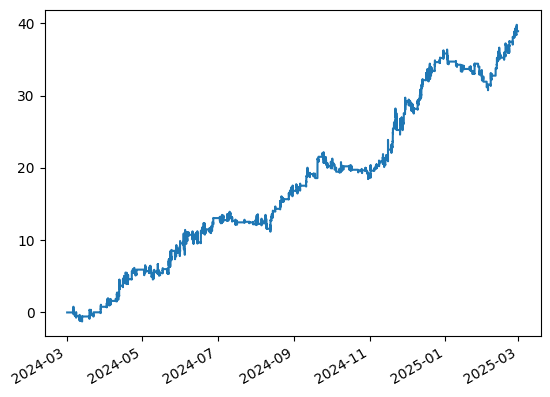

In [109]:
xx.plot()

In [110]:
#df[0:50]

In [111]:
xx[-1:]

2025-02-28 17:59:56    38.91
dtype: float64

In [112]:
df['date']=df['timestamp'].apply(lambda x: x.date())

In [113]:
# # Ensure that the index is a DatetimeIndex if not already
# xx.index = pd.to_datetime(xx.index)

# # Filter for dates in 2024
# dates_2024 = xx[xx.index.year == 2024].index.normalize().unique()

# # Iterate over each unique date in 2024 and plot
# for date in dates_2024:
#     daily_data = xx[(xx.index >= date) & (xx.index < date + pd.Timedelta(days=1))]
#     daily_data = daily_data-daily_data[0]
    
#     # Plot the data for the current date
#     plt.figure(figsize=(10, 6))
#     daily_data.plot()
#     plt.title(f"Data for {date.date()}")
#     plt.xlabel("Time")
#     plt.ylabel("Values")
#     plt.grid(True)
#     plt.show()

In [114]:
df['revenue']=-1*df['position']*df['price_level']

In [115]:
a=df.groupby('date')['revenue'].sum()

In [116]:
sum(a)

59.839999999999065

In [117]:
(a>0).value_counts()

revenue
True     127
False     77
Name: count, dtype: int64

In [118]:
len(df)

1196

In [119]:
sum(a)/len(df)

0.05003344481605273

In [120]:
reutrn_df=pd.DataFrame(xx, columns=['returns'])

reutrn_df['returns']=reutrn_df['returns'].diff()
reutrn_df=reutrn_df[reutrn_df['returns']!=0]

In [121]:
# Select odd and even indexed rows
even_index = df.iloc[1::2]['revenue'].reset_index(drop=True)  # Rows 1, 3, 5, ...
odd_index = df.iloc[0::2]['revenue'].reset_index(drop=True)   # Rows 0, 2, 4, ...

# Subtract odd-indexed rows from even-indexed rows
difference = even_index + odd_index
reutrn_df=pd.DataFrame(difference)
reutrn_df.columns=['returns']
reutrn_df

,returns
0,0.25
1,-0.36
2,-0.28
3,0.52
4,-0.47
...,...
593,0.31
594,-0.36
595,-0.26
596,1.00


Accuracy: 0.5852842809364549


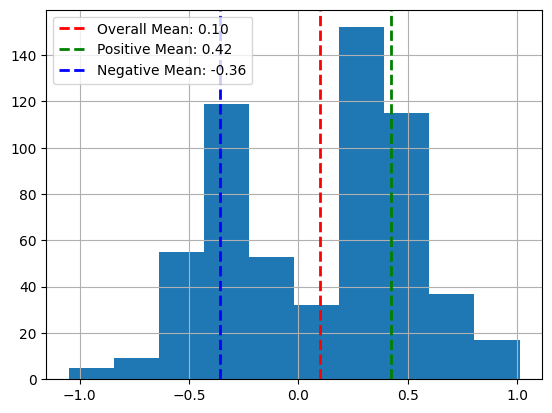

In [122]:
# Assuming 'reutrn_df' is a DataFrame and 'returns' is a column in it
overall_mean = reutrn_df['returns'].mean()
positive_mean = reutrn_df[reutrn_df['returns'] > 0]['returns'].mean()
negative_mean = reutrn_df[reutrn_df['returns'] < 0]['returns'].mean()
 
# Print accuracy
accuracy = sum(reutrn_df['returns'] > 0) / len(reutrn_df)
print('Accuracy:', accuracy)
 
# Plot histogram
reutrn_df[abs(reutrn_df['returns']) >= 0.01]['returns'].hist()
 
# Add vertical lines
plt.axvline(overall_mean, color='r', linestyle='dashed', linewidth=2, label=f'Overall Mean: {overall_mean:.2f}')
plt.axvline(positive_mean, color='g', linestyle='dashed', linewidth=2, label=f'Positive Mean: {positive_mean:.2f}')
plt.axvline(negative_mean, color='b', linestyle='dashed', linewidth=2, label=f'Negative Mean: {negative_mean:.2f}')
 
# Add a legend
plt.legend()
 
# Show plot
plt.show()

In [123]:
production_trades=pd.read_csv(r'c:\Users\andrej\Projects\LeadLag\Leadlag_profits.csv', sep=';')
production_trades['Price']=production_trades['Price'].apply(lambda x: float(x.replace(',','.')))
# Select odd and even indexed rows
even_index = production_trades.iloc[1::2]['Price'].reset_index(drop=True)  # Rows 1, 3, 5, ...
odd_index = production_trades.iloc[0::2]['Price'].reset_index(drop=True)   # Rows 0, 2, 4, ...

# Subtract odd-indexed rows from even-indexed rows
difference = even_index + odd_index
reutrn_df_prod=pd.DataFrame(difference)
reutrn_df_prod.columns=['returns']

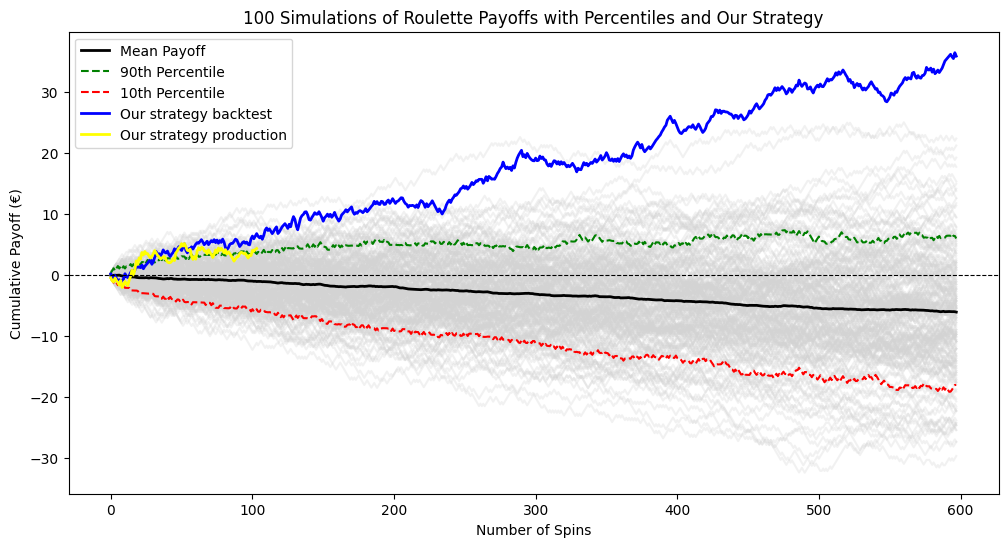

In [124]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
num_spins = int(len(df) / 2)  # Number of spins per simulation
num_simulations = 200  # Number of simulations
payoff_red = positive_mean - 0.04  # Payoff for red
payoff_black = negative_mean - 0.04  # Loss for black

# Roulette wheel setup
colors = ['red'] * 18 + ['black'] * 18 + ['green']

# Run simulations
all_simulations = []
np.random.seed(22)  # For reproducibility

for _ in range(num_simulations):
    results = np.random.choice(colors, num_spins)
    payoffs = [payoff_red if color == 'red' else payoff_black if color == 'black' else 0 for color in results]
    cumulative_payoffs = np.cumsum(payoffs)
    all_simulations.append(cumulative_payoffs)

# Convert to array for easier calculations
all_simulations = np.array(all_simulations)

# Calculate the mean, 75th percentile, and 25th percentile of cumulative payoffs
mean_payoff = all_simulations.mean(axis=0)
percentile_90 = np.percentile(all_simulations, 90, axis=0)
percentile_10 = np.percentile(all_simulations, 10, axis=0)

# Plot each simulation in one graph
plt.figure(figsize=(12, 6))
for i in range(num_simulations):
    plt.plot(all_simulations[i], color="lightgrey", alpha=0.3)

# Plot the mean of all simulations in black
plt.plot(mean_payoff, color="black", label="Mean Payoff", linewidth=2)

# Plot the 75th and 25th percentiles
plt.plot(percentile_90, color="green", linestyle="--", label="90th Percentile")
plt.plot(percentile_10, color="red", linestyle="--", label="10th Percentile")

# Plot the cumulative payoff of "Our strategy" if defined
plt.plot((reutrn_df['returns'] - 0.04).cumsum(), label="Our strategy backtest", color="blue", linewidth=2)
plt.plot((reutrn_df_prod['returns'] - 0.04).cumsum(), label="Our strategy production", color="yellow", linewidth=2)


# Plot formatting
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)  # Zero line
plt.xlabel("Number of Spins")
plt.ylabel("Cumulative Payoff (€)")
plt.title("100 Simulations of Roulette Payoffs with Percentiles and Our Strategy")
plt.legend()
plt.show()

In [125]:

# Initialize variables
counts = []
current_value = None
current_count = 0

# Loop through the data
for value in pd.DataFrame(a>0)['revenue'].apply(int):
    if value == current_value:
        current_count += 1
    else:
        if current_value is not None:
            counts.append((current_value, current_count))
        current_value = value
        current_count = 1

# Append the last sequence
counts.append((current_value, current_count))

# Display the result
counts_df = pd.DataFrame(counts, columns=['Value', 'Count'])

counts_df[counts_df['Value']==1].value_counts()

Value  Count
1      1        24
       2        10
       3         9
       4         3
       6         3
       5         2
       8         2
Name: count, dtype: int64

In [126]:
# Step 1: Calculate sign changes (+1 for positive, -1 for negative)
signs = reutrn_df['returns'].apply(lambda x: 1 if x > 0 else -1)

# Step 2: Identify streaks by checking where the sign changes
streaks = (signs != signs.shift()).cumsum()

# Step 3: Group by streak and calculate streak lengths
streak_lengths = signs.groupby(streaks).size().reset_index(name='length')
streak_lengths['sign'] = signs.groupby(streaks).first().values

# Step 4: Distribution of positive and negative streaks
streak_distribution = streak_lengths.groupby(['sign', 'length']).size().unstack(fill_value=0)

streak_distribution

length,1,2,3,4,5,6,7,8,9,14
sign,,,,,,,,,,
-1,91,45,12,4,3,0,0,0,0,0
1,68,38,28,5,8,4,1,1,1,1


In [127]:
result=[]
for date in sorted(list(set(df['timestamp'].apply(lambda x: x.date())))):
    df_day = df[df['timestamp'].apply(lambda x: x.date()) == date]
    even_index = df_day.iloc[1::2]['revenue'].reset_index(drop=True)  # Rows 1, 3, 5, ...
    odd_index = df_day.iloc[0::2]['revenue'].reset_index(drop=True)   # Rows 0, 2, 4, ...
    
    # Calculate the difference
    difference = even_index + odd_index
    
    # Create the DataFrame
    return_df = pd.DataFrame(difference)
    return_df.columns = ['returns']
    
    # Identify the first occurrence of 'returns' < -1
    mask = return_df['returns'] < -1.2
    row_index = mask.idxmax()  # Get the index of the first occurrence
    
    # If a value < -1 is found, slice the DataFrame to remove all subsequent rows
    if mask.any():
        return_df = return_df.iloc[:row_index+1]
        
    #print(return_df)
    result.append(return_df)
    
    
sum(pd.concat(result)['returns'])

59.839999999999065

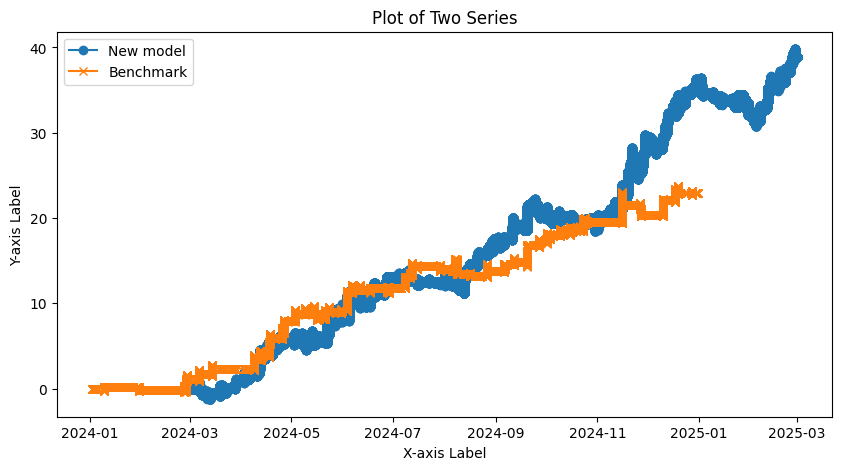

In [128]:
%store -r xx2

# Create the plot
plt.figure(figsize=(10, 5))
plt.plot(xx, label="New model", marker='o')
plt.plot(xx2, label="Benchmark", marker='x')


# Add labels and title
plt.xlabel("X-axis Label")
plt.ylabel("Y-axis Label")
plt.title("Plot of Two Series")

# Add legend
plt.legend()

# Show the plot
plt.show()

In [129]:
# Group rows by pairs and calculate the required aggregations
reduced_df = df.groupby(df.index // 2).agg({
    "timestamp": "first",
    "coef2": "max",  # Take the max coef2 from each pair
    "date": "first",  # Retain the first date
    "revenue": "sum"  # Sum revenue by pairs
}).reset_index(drop=True)

reduced_df['revenue']=reduced_df['revenue']-2*br_fee

# Aggregate by date
b = reduced_df.groupby('date')[['revenue', 'coef2', 'timestamp']].agg({
    'revenue': 'sum',
    'coef2': 'max',
    'timestamp': 'count'
})
b['revenue_per_trade'] = b['revenue'] / b['timestamp']

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(b['coef2'], b['revenue_per_trade'], alpha=0.7, edgecolors='k')
plt.title('Scatter Plot: coef2 vs revenue_per_trade')
plt.xlabel('coef2')
plt.ylabel('Revenue Per Trade')
plt.grid(True)
plt.show()

# Create bins for coef2
bins = np.linspace(reduced_df['coef2'].min(), reduced_df['coef2'].max(), 5)
reduced_df['coef2_bin'] = pd.qcut(reduced_df['coef2'], 5)  # Bin the data
reduced_df['accuracy'] = (reduced_df['revenue'] > 0).astype(int)

# Group by bins and calculate statistics
binned_stats = reduced_df.groupby('coef2_bin').agg(
    avg_revenue=('revenue', 'mean'),
    num_trades=('timestamp', 'count'),
    total_profit=('revenue', 'sum'),
    accuracy=('accuracy', 'mean')
).reset_index()

# Plot the binned averages and additional info
bin_centers = [interval.mid for interval in binned_stats['coef2_bin']]

fig, ax1 = plt.subplots(figsize=(12, 8))

interval_widths = [interval.right - interval.left for interval in binned_stats['coef2_bin']]


# Bar plot for average revenue per trade
ax1.bar(bin_centers, binned_stats['avg_revenue'], width=interval_widths, alpha=0.7, label='Revenue', color='yellow', edgecolor='k')
ax1.set_ylabel('Average Revenue Per Trade', color='blue')
ax1.set_xlabel('coef2 (Binned)')
ax1.legend(loc='upper left')
ax1.grid(True)

# Line plot for number of trades and accuracy
ax2 = ax1.twinx()
ax2.plot(bin_centers, binned_stats['num_trades'], label='Number of Trades', color='red', marker='o')
ax2.plot(bin_centers, binned_stats['accuracy'] * 100, label='Accuracy (%)', color='green', marker='s')
ax2.set_ylabel('Number of Trades / Accuracy (%)', color='black')

# Add total profit as text on the bars
for x, y, profit, acc, trades in zip(
    bin_centers, 
    binned_stats['avg_revenue'], 
    binned_stats['total_profit'], 
    binned_stats['accuracy'], 
    binned_stats['num_trades']
):  
    ax1.text(x, y + 0.05 * y, f"Profit: {profit:.1f}", ha='center', va='bottom', fontsize=9, color='black')
    ax2.text(x, binned_stats['accuracy'].max() * 100, f"Acc: {acc*100:.1f}%", ha='center', va='bottom', fontsize=9, color='green')
    ax2.text(x + 0.01, trades, f"{trades}", ha='left', va='center', fontsize=9, color='red')  # Right next to trade markers




ax2.legend(loc='upper right')

# Set plot title and layout
plt.title('Binned Statistics: Avg Revenue, Trades, Profit, and Accuracy')
plt.tight_layout()
plt.show()

KeyError: "Column(s) ['coef2'] do not exist"

# Misc

In [ ]:
# from support_functions import calculate_MACD, calculate_lead_lag_triggers, calculate_regression_model_price, calc_vol_intensity_index


# df_lag = data_lead.reset_index(drop=True)
# df_lead=data_lead
# #df_lead = df_lead[['datetime', 'trd_price', 'trd_side']].dropna().reset_index(drop=True)

# df_lag['timestamp']=df_lag['datetime']
# df_lead['timestamp']=df_lead['datetime']


# df_lag = calculate_MACD(df_lag, 6, 14)
# df_lag = calculate_MACD(df_lag, 12, 26)
# df_lag = calculate_MACD(df_lag, 18, 38)
# df_lag = calculate_MACD(df_lag, 30, 60)

# df_lead = calculate_regression_model_price(df_lead, df_lag, 10, 10, 3)

# df_lag['tag'] = 'lag'
# df_lead['tag'] = 'lead'

# #del df_lag['level_0']

# df_lag = pd.concat([df_lag, df_lead[
#     ['datetime', 'timestamp', 'tag', 'trd_price', 'lag_price_predicted', 'lag_price_predicted_datetime',
#      'lag_price_tick', 'coef1', 'coef2', 'lead_price_tick']].reset_index(drop=True)]).reset_index(
#     drop=True).sort_values('datetime').reset_index()

# del df_lag['level_0'], df_lag['index']

# # Convert the timestamp to date and set it as a separate column if not already done
# df_lag['date'] = df_lag['datetime'].dt.date

# df_lag = calc_vol_intensity_index(df_lag, 3, 'lead')
# df_lag = calc_vol_intensity_index(df_lag, 5, 'lead')
# df_lag = calc_vol_intensity_index(df_lag, 10, 'lead')
# df_lag = calc_vol_intensity_index(df_lag, 3, 'lag')
# df_lag = calc_vol_intensity_index(df_lag, 5, 'lag')
# df_lag = calc_vol_intensity_index(df_lag, 10, 'lag')

# # Forward fill within each day
# df_lag['bid_price'] = df_lag.groupby('date')['bid_price'].ffill()
# df_lag['ask_price'] = df_lag.groupby('date')['ask_price'].ffill()
# df_lag['mid_price'] = df_lag.groupby('date')['mid_price'].ffill()
# df_lag['MACD_6_14'] = df_lag.groupby('date')['MACD_6_14'].ffill()
# df_lag['MACD_12_26'] = df_lag.groupby('date')['MACD_12_26'].ffill()
# df_lag['MACD_18_38'] = df_lag.groupby('date')['MACD_18_38'].ffill()
# df_lag['MACD_30_60'] = df_lag.groupby('date')['MACD_30_60'].ffill()


# df_lag['VII_3_ratio'] = df_lag['VII_lead_3'] / df_lag['VII_lag_3'].replace(0, 1e-6)
# df_lag['VII_5_ratio'] = df_lag['VII_lead_5'] / df_lag['VII_lag_5'].replace(0, 1e-6)
# df_lag['VII_10_ratio'] = df_lag['VII_lead_10'] / df_lag['VII_lag_10'].replace(0, 1e-6)

# df_lag = df_lag.dropna(subset=['bid_price', 'ask_price', 'mid_price'])

# df_lag['ba_spread']=df_lag['ask_price']-df_lag['bid_price']

# # scoring the XGB model

# df_lag['price_diff']=df_lag['lag_price_predicted']-df_lag['ask_price']

In [ ]:
# df_lag['DELTA_MACD']=df_lag['MACD_6_14']-df_lag['MACD_18_38']

In [ ]:
# feature_cols = [
#     'MACD_6_14',
#     'MACD_12_26',
#     'MACD_18_38',
#     'MACD_30_60',
#     'VII_lead_3',
#     'VII_lead_5',
#     'VII_lead_10',
#     'VII_lag_3',
#     'VII_lag_5',
#     'VII_lag_10',

#     'VII_3_ratio',
#     'VII_5_ratio',
#     'VII_10_ratio',

#     'price_diff',
#     'ba_spread',
#     'DELTA_MACD']


In [ ]:
# even_index = df.iloc[1::2][['timestamp','revenue']].reset_index(drop=True)  # Rows 1, 3, 5, ...
# odd_index = df.iloc[0::2][['timestamp','revenue']].reset_index(drop=True)   # Rows 0, 2, 4, ...

# # Subtract odd-indexed rows from even-indexed rows

# a=pd.concat([odd_index['timestamp'], even_index.rename(columns={'revenue':'buy_sell'})['buy_sell'],((even_index['revenue'] + odd_index['revenue'])>0).apply(int)], axis=1).merge(df_lag[df_lag['tag']=='lead'], how='left', on='timestamp')

In [ ]:
# a=a.dropna(subset=feature_cols).replace([np.inf, -np.inf], [1000000000, -100000000], inplace=False)
# a=a[a['buy_sell']<0]

In [ ]:
# import mofr 
# result=[]
# for feat in feature_cols:
#     gini=mofr.metrics.gini(a['revenue'], a[feat].apply(float))
#     result.append((feat,gini))
    
# df_result = pd.DataFrame(result, columns=['Feature', 'Gini'])

# # Sort DataFrame by the absolute value of the 'Gini' column
# df_result_sorted = df_result.reindex(df_result['Gini'].abs().sort_values(ascending=False).index)

# # Display sorted DataFrame
# df_result_sorted